# Softmax y Sparsemax Functions

**Author**: <a href="https://www.linkedin.com/in/pedro-ramon-ventura-gomez/">Pedro Ramón Ventura Gómez</a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

This notebook explains the Softmax and Sparsemax functions and their use in a specific case: assigning weights to portfolio assets during an optimization process.

I have used these functions together with <a href="https://www.linkedin.com/in/christian-oliva-moya-ingeniero/">Christian Oliva Moya</a> while we explored the possibility of implementing a multi-objective portfolio optimization framework in Tensorflow.

In [2]:
def plot_2_vectors(
    z: np.ndarray,
    s: np.ndarray,
    x_labels: list,
    y_labels: list,
    titles: list,
    plot_bar_text: bool = False,
    fs=(10, 3),
) -> None:

    n = len(z)
    if n != len(s):
        raise ValueError("Vectors z and s must have the same length.")

    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=fs)

    # Values of z.
    axs[0].bar(range(n), z)
    axs[0].set_xlabel(x_labels[0])
    axs[0].set_ylabel(y_labels[0])
    axs[0].set_title(titles[0])

    if plot_bar_text is True:
        for i, v in enumerate(z):
            axs[0].text(i, v, f"{v:.2f}", ha="center", va="bottom")

    # Values of s.
    axs[1].bar(range(n), s)
    axs[1].set_xlabel(x_labels[1])
    axs[1].set_ylabel(y_labels[1])
    axs[1].set_title(titles[1])

    if plot_bar_text is True:
        for i, v in enumerate(s):
            axs[1].text(i, v, f"{v:.2f}", ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

## Softmax


This function is one of the most used in classification algorithms as it converts the algorithm's output into a vector [0, 1] whose sum is 1. For example, it is used as an activation function in the last layer of a neural network whose goal is to classify into multiple classes, resulting in a vector that can be interpreted as the probability that the input belongs to a specific class.

Its formula is as follows:

$ \sigma (\mathbf {z} )_{j}={\frac {e^{z_{j}}}{\sum _{k=1}^{K}e^{z_{k}}}} $ for $j = 1, …, K$

Although this alternative version is commonly used to avoid *overflow* in systems when $x$ is very large:

$M = \max (\mathbf {z})$,

$ \sigma (\mathbf {z} )_{j}={\frac {e^{z_{j}-M}}{\sum _{k=1}^{K}e^{z_{k}-M}}} $ for $j = 1, …, K$

This is because adding a constant to all components of $\mathbf{z}$ does not change the value of Softmax:

$ {\frac {e^{z_{j}-M}}{\sum _{k=1}^{K}e^{z_{k}-M}}}={\frac {e^{-M}e^{z_{j}}}{e^{-M}\sum _{k=1}^{K}e^{z_{k}}}}={\frac {e^{z_{j}}}{\sum _{k=1}^{K}e^{z_{k}}}} $ for $j = 1, …, K$

In [3]:
def softmax(z: np.ndarray) -> np.ndarray:
    """Calculates the softmax function of a vector z.

    Args:
        z (np.ndarray): Input vector.

    Returns:
        np.ndarray: Output vector.
    """
    e_z = np.exp(z - np.max(z))
    return e_z / e_z.sum(axis=0, keepdims=True)

In [4]:
rng = np.random.default_rng(42)
n = 10  # Number of elements.
z1 = rng.normal(size=n, loc=0, scale=1)  # Input vector.
s1 = softmax(z1)  # Output vector.

print(f"Values of z = {z1}")
print(f"Values of s = {s1}")
print(f"Sum of s = {s1.sum()}")  # The sum of s must be 1.0.

Values of z = [ 0.30471708 -1.03998411  0.7504512   0.94056472 -1.95103519 -1.30217951
  0.1278404  -0.31624259 -0.01680116 -0.85304393]
Values of s = [0.13457633 0.03507296 0.21015926 0.25416385 0.01410288 0.02698375
 0.11275923 0.07232514 0.09757422 0.04228238]
Sum of s = 1.0


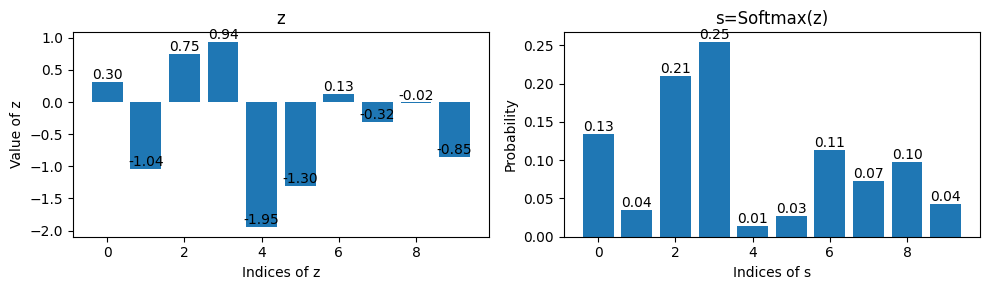

In [5]:
plot_2_vectors(
    z1,
    s1,
    x_labels=["Indices of z", "Indices of s"],
    y_labels=["Value of z", "Probability"],
    titles=["z", "s=Softmax(z)"],
    plot_bar_text=True,
    fs=(10, 3),
)  # Plot the vectors z and s

But what happens with Softmax? This function assigns a value to all positions of the output vector ($s$) between 0 and 1, and unless the smallest value of the input vector ($z$) is very negative, it will never assign an absolute zero to any position.

Let's see.

In [6]:
z = np.array([-1, 0, 1])  # Input vector.
s = softmax(z)  # Output vector.

print(f"Values of z = {z}")
print(f"Values of s = {s}")
print(f"Sum of s = {s.sum()}")  # The sum of s must be 1.0.

Values of z = [-1  0  1]
Values of s = [0.09003057 0.24472847 0.66524096]
Sum of s = 0.9999999999999999


In [7]:
z = np.array([-100, 0, 1])  # Input vector.
s = softmax(z)  # Output vector.

print(f"Values of z = {z}")
print(f"Values of s = {s}")
print(f"Sum of s = {s.sum()}")  # The sum of s must be 1.0.

Values of z = [-100    0    1]
Values of s = [1.00048252e-44 2.68941421e-01 7.31058579e-01]
Sum of s = 1.0


In [8]:
z = np.array([-1000, 1, 2])  # Input vector.
s = softmax(z)  # Output vector.

print(f"Values of z = {z}")
print(f"Values of s = {s}")
print(f"Sum of s = {s.sum()}")  # The sum of s must be 1.0.

Values of z = [-1000     1     2]
Values of s = [0.         0.26894142 0.73105858]
Sum of s = 1.0


At the beginning of the notebook, we referred to the use case where we have used this function for convenience: the assignment of weights to an investment portfolio during an optimization process.

Suppose we are building an investment portfolio with the following constraints:
* Short positions are not allowed (all weights must be positive).
* The sum of all asset weights must be 1 (100% allocation).

At first glance, Softmax helps us with this due to the inherent construction of the function, as we have seen earlier. The problem arises when you want to optimize your portfolio for any given objective, and the algorithm must assign weights considering a very large investment universe.

Let’s see.

In [9]:
rng = np.random.default_rng(42)

n = 500  # Number of assets in our investment universe.
z2 = rng.normal(size=n, loc=0, scale=1)  # Weights assigned by the optimization algorithm.
s2 = softmax(z2)  # Positive weights that sum to 1.

print(f"Sum of s = {s2.sum()}")  # The sum of s must be 1.0.

Sum of s = 1.0


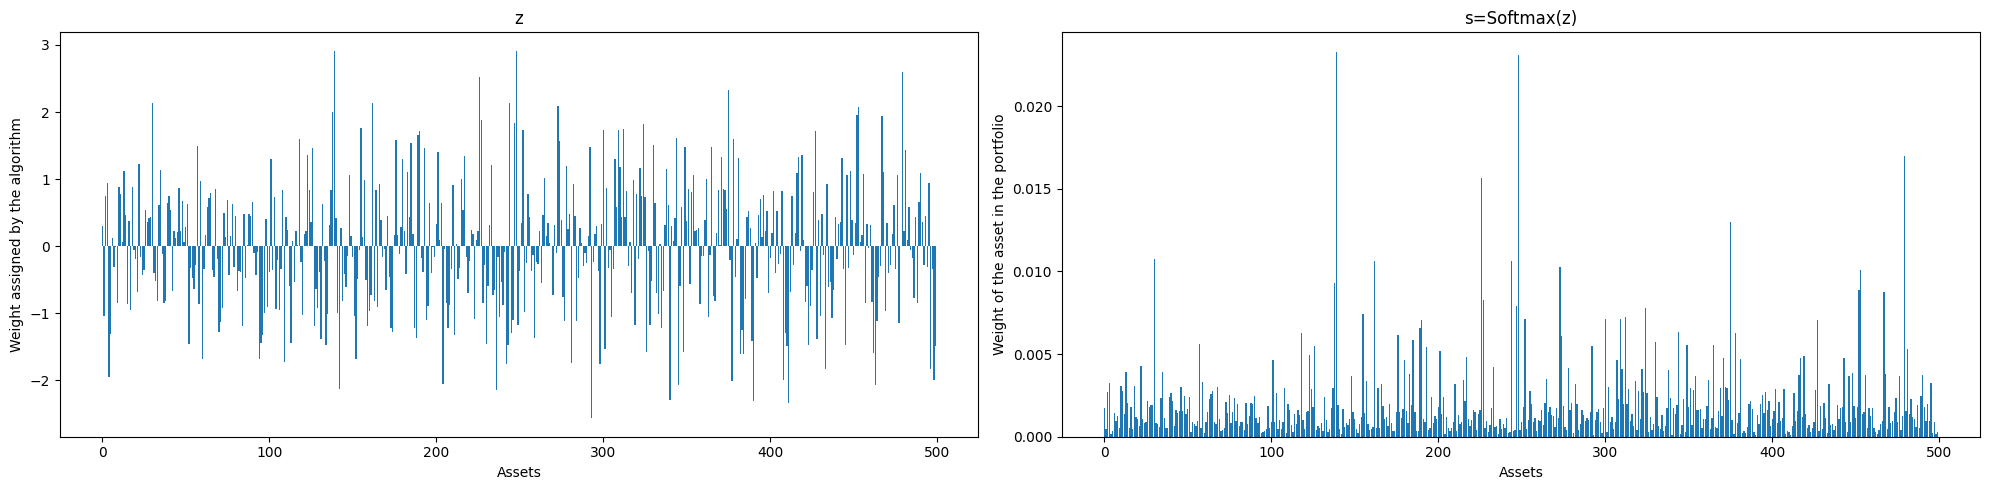

In [10]:
plot_2_vectors(
    z2,
    s2,
    x_labels=["Assets", "Assets"],
    y_labels=["Weight assigned by the algorithm", "Weight of the asset in the portfolio"],
    titles=["z", "s=Softmax(z)"],
    plot_bar_text=False,
    fs=(20, 5),
)

We see that when using Softmax, all assets are assigned a weight.

In [11]:
s2[s2 == 0.0]

array([], dtype=float64)

In [12]:
np.sort(s2)[:10]

array([9.70874447e-05, 1.22566579e-04, 1.25482596e-04, 1.27865764e-04,
       1.47670210e-04, 1.49938352e-04, 1.59060887e-04, 1.60618539e-04,
       1.62730979e-04, 1.70502202e-04])

In [13]:
np.sort(s2)[-10:]

array([0.0100895 , 0.01025416, 0.01062261, 0.01063087, 0.01076352,
       0.0129639 , 0.01567378, 0.01698259, 0.02309422, 0.02329824])

At this point, we could assume that those that are, for example, below 0.001 are 0.0.

In [14]:
s2_mod = s2.copy()  # Copy the vector s2.
s2_mod[s2_mod <= 0.001] = 0.0  # Remove very small weights.

In this case, we no longer have 100% of the capital allocated.

In [15]:
print(np.sum(s2))
print(np.sum(s2_mod))

1.0
0.8824053773137016


Well, we could normalize the weights so that they sum to 1, in which case they would no longer be the weights assigned by the optimizer, but slightly different ones.

In [16]:
s2_mod = s2_mod / np.sum(s2_mod)  # Normalize weights to sum up 1.

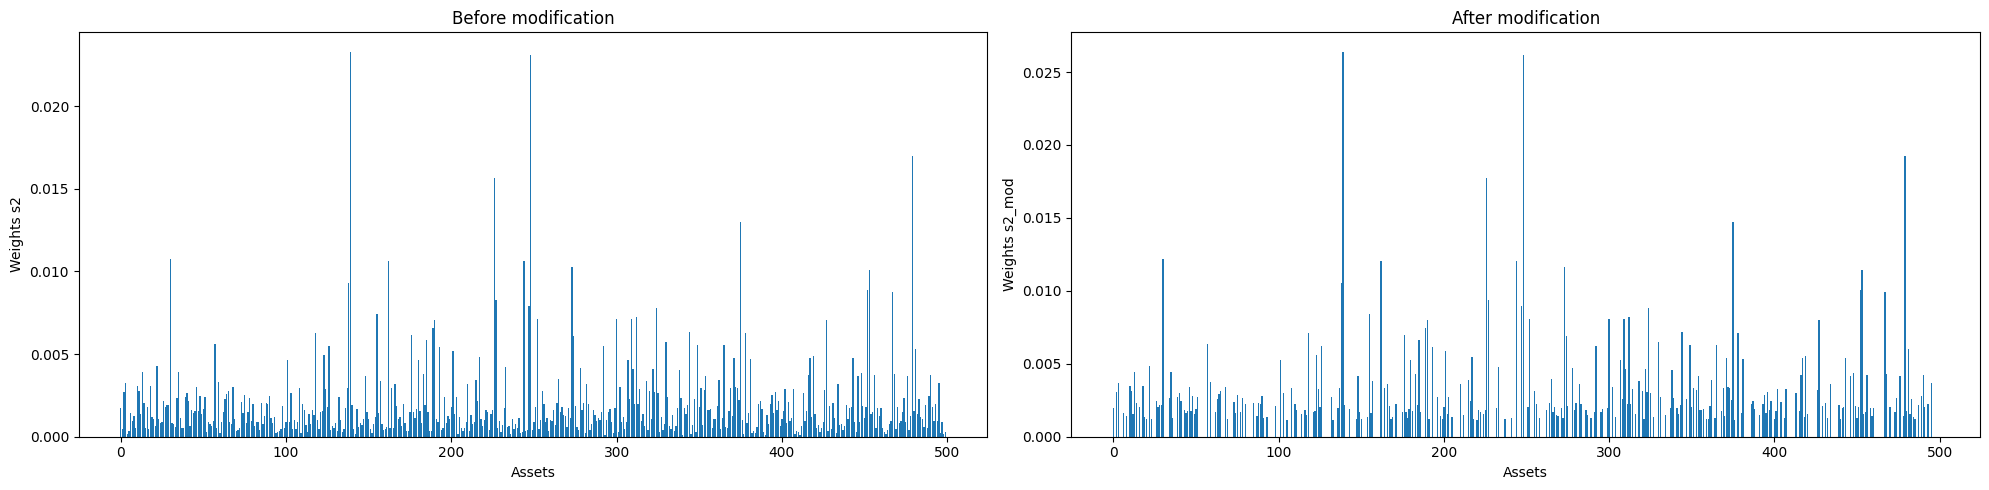

Maximum of s2 = 0.02329823698312446
Maximum of s2_mod = 0.02640309950745208


In [17]:
plot_2_vectors(
    s2,
    s2_mod,
    x_labels=["Assets", "Assets"],
    y_labels=["Weights s2", "Weights s2_mod"],
    titles=["Before modification", "After modification"],
    plot_bar_text=False,
    fs=(20, 5),
)

print(f"Maximum of s2 = {np.max(s2)}")
print(f"Maximum of s2_mod = {np.max(s2_mod)}")

Although the vector $z_2$ used as input for Softmax earlier could be perfectly valid as the result of an optimizer, depending on the technique used, let us now test with a vector that, as a result of optimization, already has positions at 0.0. The result when using Softmax is also striking.

Let’s see.

In [18]:
rng = np.random.default_rng(42)

n = 500  # Number of assets in our investment universe.
z3 = rng.normal(size=n, loc=0, scale=1)
z3[z3 < 0.0] = 0.0  # Remove negative weights.
s3 = softmax(z3)  # Positive weights that sum to 1.

print(f"Sum of s = {s3.sum()}")  # The sum of s must be 1.0.

Sum of s = 0.9999999999999999


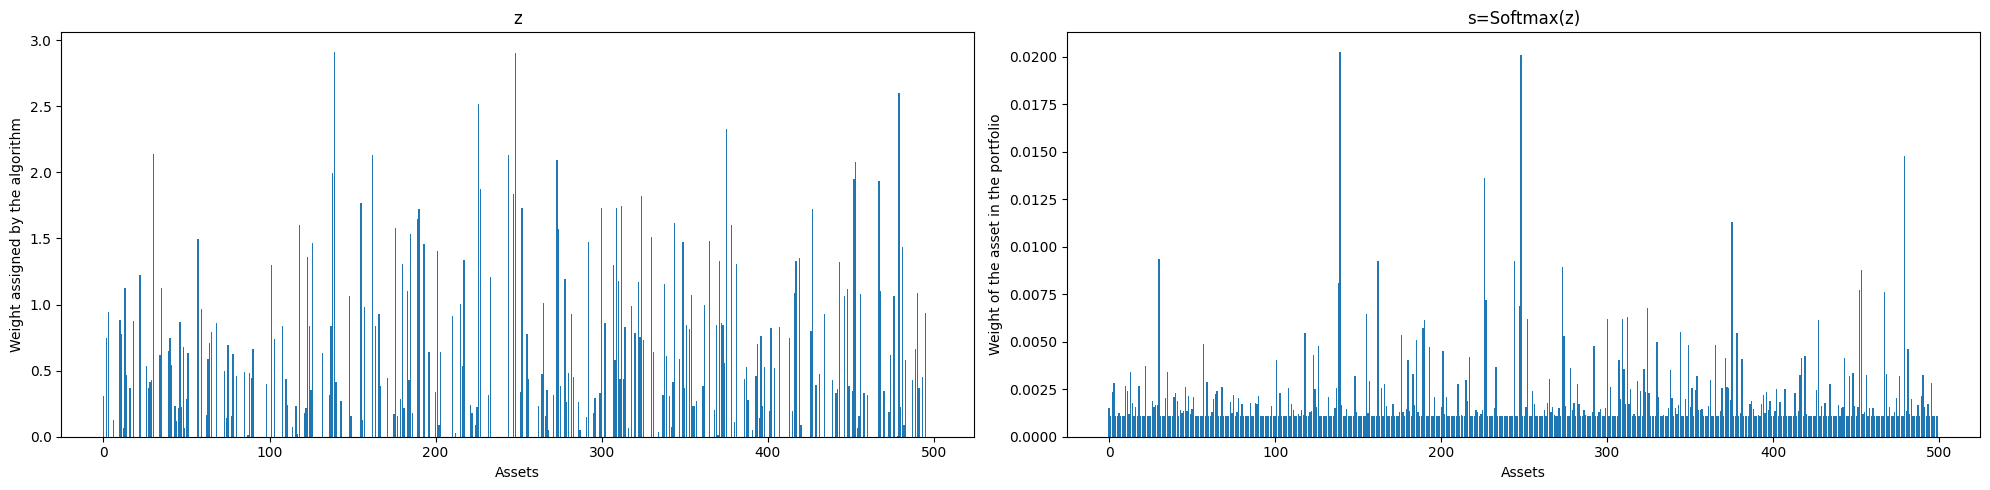

In [19]:
plot_2_vectors(
    z3,
    s3,
    x_labels=["Assets", "Assets"],
    y_labels=["Weight assigned by the algorithm", "Weight of the asset in the portfolio"],
    titles=["z", "s=Softmax(z)"],
    plot_bar_text=False,
    fs=(20, 5),
)

What happened? Since $e^0=1$, when calculating the Softmax for the position $i$ of the vector that equals $0.0$

In [20]:
z_i = 0.0  # Peso del activo i.
e_z = np.exp(z3 - np.max(z3))
e_z_i = np.exp(z_i - np.max(z3))
e_z_i / e_z.sum(axis=0, keepdims=True)

array([0.0011002])

Therefore, the result of applying Softmax to this type of input also produces an undesired outcome.

In [21]:
np.sort(s3)

array([0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 ,
       0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 ,
       0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 ,
       0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 ,
       0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 ,
       0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 ,
       0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 ,
       0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 ,
       0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 ,
       0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 ,
       0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 ,
       0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 ,
       0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 ,
       0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 ,
       0.0011002 , 0.0011002 , 0.0011002 , 0.0011002 , 0.00110

How do we solve this problem? That is, we need a function with the same behavior as Softmax in terms of transforming each position of a vector to the range [0, 1] and the sum of all its positions being 1, but at the same time we need it to support some positions being exactly 0.0.

## Sparsemax

The **Sparsemax** function was proposed by Martins and Astudillo as a sparse alternative to Softmax for attention mechanisms and multi-label classification [1].

> **Reference**  
> [1] Martins, A., & Astudillo, R. (2016). *From Softmax to Sparsemax: A Sparse Model of Attention and Multi-Label Classification*. In M. F. Balcan & K. Q. Weinberger (Eds.), Proceedings of The 33rd International Conference on Machine Learning (Vol. 48, pp. 1614–1623). PMLR.

This function calculates a threshold based on the input vector, values smaller than this threshold are set to zero, and the rest are adjusted to sum to one.

Key steps of the function defined below:

1. **Descending order** (`u`):  
   We need to process the values from largest to smallest to find the correct "threshold" point, beyond which values are set to zero.

2. **Cumulative sum** (`cssv`):  
   Allows calculating, for each position $k$ of $u$, the sum $\sum_{i=1}^k u_i$.

3. **Calculation of $\rho$** (`rho`):  
   $\rho$ indicates, for each position, the size of the segment of $u$ considered.

4. **Validity mask** (`condition`):  
   Identifies how many of the first values satisfy $u_i + \frac{s - \text{cssv}_i}{\rho} > 0$; this defines up to where the projection should "fill."

5. **Calculation of $\theta$** (`theta`):  
   This is the amount that must be subtracted (uniformly) from all components of $v$ so that they sum exactly to $s$ after being trimmed to zero. In other words, it is the total excess of the sum of all values of $v$ over $s$, divided by the number of components $rho_{max}$ that will not be zero.

6. **Final projection** (`w`):  
   $\max(v - \theta, 0)$ ensures non-negativity and a sum of $s$.

In [22]:
def sparsemax(v, s=1, axis=0):
    """
    Projects the array v onto the simplex { w : sum(w)=s, w>=0 } along the given axis.

    Args:
        v (np.ndarray): Input array.
        s (float, optional): Desired sum of the projected components. Default is 1.
        axis (int, optional): Axis along which the projection is performed. Default is 0.

    Returns:
        np.ndarray: Projected array, same shape as v.
    """
    v = np.asarray(v, dtype=float)
    # 1) Sort v in descending order along the given axis
    u = np.flip(np.sort(v, axis=axis), axis=axis)
    # 2) Cumulative sum along the axis
    cssv = np.cumsum(u, axis=axis)
    # 3) Build rho = [1, 2, ..., K] with dimensions suitable for broadcasting
    K = v.shape[axis]
    rho = np.arange(1, K + 1, dtype=v.dtype)
    shape = [1] * v.ndim
    shape[axis] = K
    rho = rho.reshape(shape)
    # 4) Determine the mask of elements that satisfy the condition u + (s - cssv)/rho > 0
    condition = u + (s - cssv) / rho > 0
    # 5) rho_max = number of elements that satisfy the condition along the axis
    rho_max = np.sum(condition, axis=axis, keepdims=True)
    # 6) Calculate theta
    #    Sum only the valid elements (u * condition), subtract s, and divide by rho_max
    sum_u = np.sum(u * condition, axis=axis, keepdims=True)
    theta = (sum_u - s) / rho_max
    # 7) Project: w = max(v - theta, 0)
    w = np.maximum(v - theta, 0)
    return w

Applying Sparsemax to the vectors $z_2$ and $z_3$ used earlier, we observe that the results are radically different, allowing us to obtain weight vectors where we do not assign weights to all assets.

The fact that it is a highly concentrated portfolio is not relevant in this case, as it is a random allocation of values, and the optimizer, in any case, would adjust the allocation appropriately to meet its objectives.

In [23]:
s2_sparse = sparsemax(z2)

print(f"Sum of s = {s2_sparse.sum()}")  # The sum of s should be 1.0.

Sum of s = 0.9999999999999996


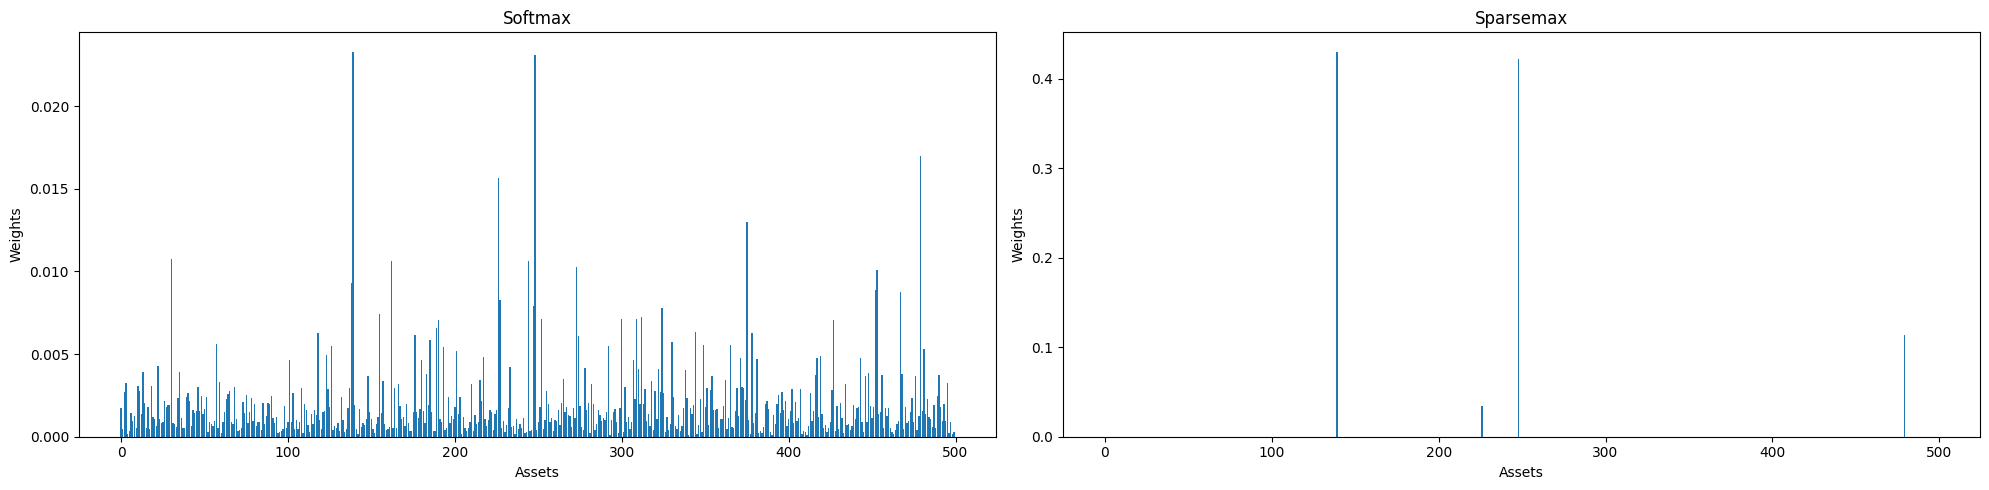

In [24]:
plot_2_vectors(
    s2,
    s2_sparse,
    x_labels=["Assets", "Assets"],
    y_labels=["Weights", "Weights"],
    titles=["Softmax", "Sparsemax"],
    plot_bar_text=False,
    fs=(20, 5),
)

In [25]:
s3_sparse = sparsemax(z3)

print(f"Sum of s = {s3_sparse.sum()}")  # the sum of s should be 1.0.

Sum of s = 0.9999999999999996


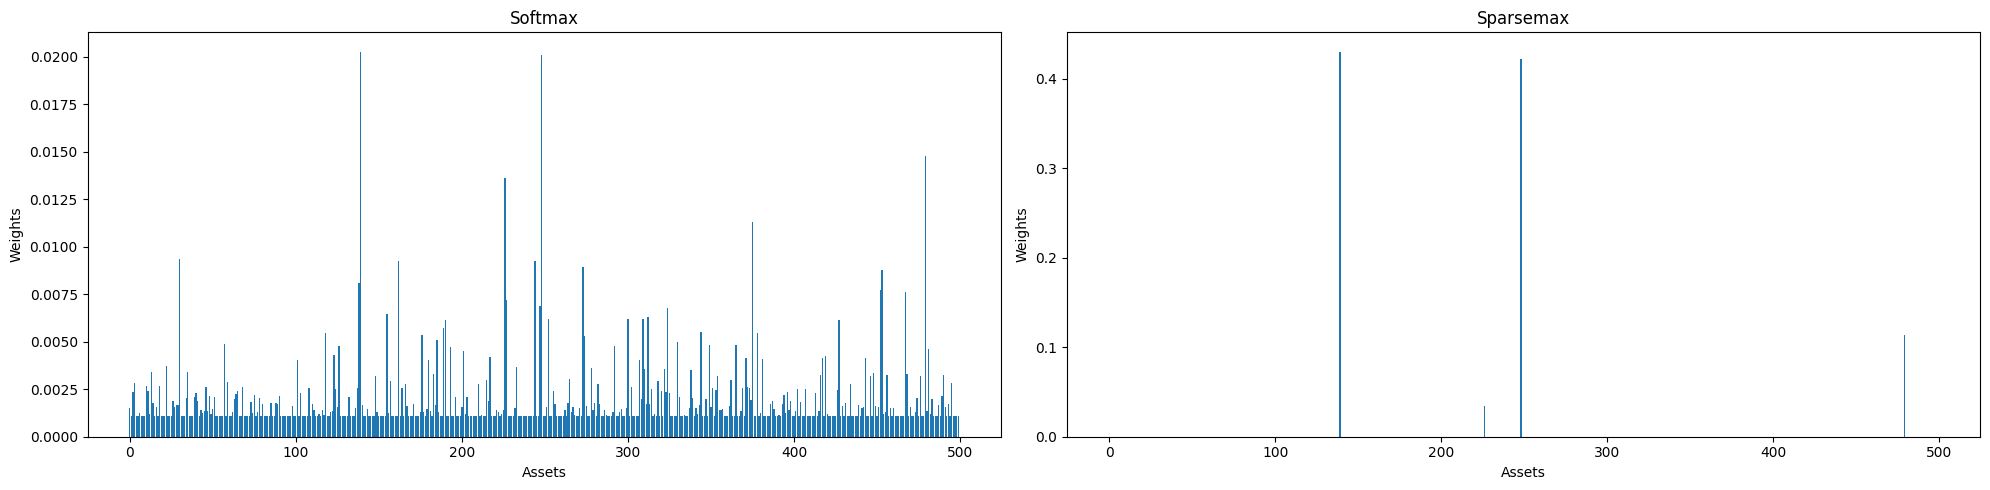

In [26]:
plot_2_vectors(
    s3,
    s3_sparse,
    x_labels=["Assets", "Assets"],
    y_labels=["Weights", "Weights"],
    titles=["Softmax", "Sparsemax"],
    plot_bar_text=False,
    fs=(20, 5),
)

In [27]:
# Export to HTML
!jupyter nbconvert --to html FuncionesSoftmaxSparsemax.ipynb

[NbConvertApp] Converting notebook FuncionesSoftmaxSparsemax.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 570309 bytes to FuncionesSoftmaxSparsemax.html
